In [2]:
using Plots
using LaTeXStrings
using Statistics
using Base.Threads

include("../fft.jl")
include("gratings.jl")
include("zoom.jl")
# using FFTW
# function fft2(image)
#     return fftshift(fft(ifftshift(image)))
# end

zoom_plot (generic function with 4 methods)

In [3]:
function fftfreq(n::Int, d::Real=1)
    val = 1.0 / (n * d)
    N = div(n, 2)
    if iseven(n)
        return vcat(0:N-1, -N:-1) * val
    else
        return vcat(0:N, -(N): -1) * val
    end
end

fftfreq (generic function with 2 methods)

In [4]:
function Wavelength(E::T) where T <: Real
    hc::T = 12.398 #keV*Angstrom
    # h = 6.582119e-16 #eV*sec
    # mc2 = 511 #keV
    E₀::T = 511.0 #keV
    return hc/sqrt(abs(E*(2*E₀ + E)))
end


function Focus(E::T, Cs::T, nᵢ=1)::T where T <: Real
    return sqrt((2*nᵢ-0.5)*Cs*Wavelength(E))
end
kmax(E, Cs) = (6/((Cs*Wavelength(E)^3)))^(1/4)

Diff_Image(image, c=0.1) = @. log1p(c*abs(image))

Diff_Image (generic function with 2 methods)

In [5]:
E = 80.0 #keV
Cs = 1 #mm
Cs = Cs * 1e7 #convert to Angstroms

N = 2^10

λ(E) = Wavelength(E)
Δf(E, Cs) = Focus(E, Cs)
χ(k) = @. π*λ(E)*k^2*(0.5*Cs*λ(E)^2*k^2 - Δf(E, Cs))


χ (generic function with 1 method)

\begin{align*}
    u, v \to \frac{x}{\lambda  f}, \frac{y}{\lambda  f}, 
\end{align*}

In [6]:
σ(E) = 2π/(Wavelength(E)*E) * (511 + E)/(2*511 + E)
"""
lets estimate n and κ from CjW thesis. Lets assume there is a 10 phase_reconstruced
decay and pi/2 phase shift after 50nm
"""
λ_nm = Wavelength(E)/10 # convert to nm
#given
σU = 0.15 
α = 0.008 
distance_est = 50 #nm
κ = α * (λ_nm/(2*π)) # this is the attenuation coefficient 


"""
Assuming that CJW uses 300keV electrons
"""
σ_cjw = σ(300.0) * 10 # per nm 
U_mip = σU/σ_cjw 
println(κ,"  ", U_mip)
# κ = 0
"""
    I believe that my kappa and U_mip values are wrong since using just the values reported in CJW, the results are very different
"""

5.316501734433631e-6  0.022983624805675437


"    I believe that my kappa and U_mip values are wrong since using just the values reported in CJW, the results are very different\n"

In [7]:
periods = 16
x = collect(range(-10e4, 10e4, N))
y = copy(x);

In [8]:
function centered_disks(N; disk_scale=1)
    """
        Create a centered disk aperture of size N x N
    """
    upper = (N-1)/2 + 0.1
    lower = (-N+1)/2
    x = collect(lower:1:upper)
    y = collect(lower:1:upper)

    r = @. sqrt(x'^2 + y^2)
    disk = r.<=N/2/disk_scale
end

function transmission_func(g::AbstractMatrix, aperature::Union{AbstractMatrix, Bool}=true; 
            σU::Real=π/21, α::Real=0.008)
    # mask selection: matrix aperture, disk when true, or no mask when false
    mask = aperature isa AbstractMatrix ? aperature :
           aperature ? centered_disks(size(g,1)) :
           ones(eltype(g), size(g))

    # apply transmission (preserves previous behavior; pass σU=0.15 if you need that legacy value)
    t = @. cis((σU + 1im * α) * g / 10 * mask) * mask
    return t
end

transmission_func (generic function with 2 methods)

In [9]:

function transform_coordinates(x, y, E, f)
    """
    transform x and y coordinates from front focal plane to back focal plane. it assumes that
    the ff-plane coordinates and focal point are in units of Angstroms. E is units of keV.
    """
    ΔLx, ΔLy = x[2] - x[1], y[2] - y[1]
    Nx, Ny = length(x), length(y)
    kx, ky = fftshift(fftfreq(Nx, ΔLx)), fftshift(fftfreq(Ny, ΔLy))
    kx_transformed = @. kx * Wavelength(E) * f
    ky_transformed = @. ky * Wavelength(E) * f
    return kx_transformed, ky_transformed
end
function chain_transforms(x0, y0, focal_lengths, E)
    coords = []
    x, y = x0, y0
    push!(coords, (x, y))
    for f in focal_lengths
        x, y = transform_coordinates(x, y, E, f)
        push!(coords, (x, y))
    end
    return coords
end

chain_transforms (generic function with 1 method)

In [10]:
function radial_grid(x,y)
    Nx, Ny = length(y), length(x)

    upperx = (Nx-1)/2 + 0.1
    lowerx = (-Nx+1)/2
    rx = collect(lowerx:1:upperx)

    uppery = (Ny-1)/2 + 0.1
    lowery = (-Ny+1)/2
    ry = collect(lowery:1:uppery)

    return @. sqrt(rx'^2 + ry^2)
end
function radial_disks(coords, disk_rel_scales)
    r_dists = [(@. sqrt(x'^2 + y^2)) for (x,y) in coords[1:3]]
    r_ratios = [maximum(r_dist)/maximum(r_dists[1]) for r_dist in r_dists]
    
    r = radial_grid(coords[1]...)
    disks = [r.<=N/2/ratio * disk_rel_scales[i] for (i,ratio) in enumerate(r_ratios)]
    return disks, r_dists
end


function gaussian_object(phase_desired::Real, σ::Real, dx2::Real, loc::Tuple{Int64, Int64})
    #given
    σU = 0.15 
    α = 0.008 
    r = radial_grid(x,y)
    A = phase_desired * 10 * sqrt(2π * σ^2) * inv(σU) # from t = @. cis((σU + 1im * α)*gaussian/10);
    gaussian = @. A * inv(sqrt(2π)σ) * exp(-r^2 * inv(2 * σ^2))
    gaussian = circshift(gaussian, loc)
    ψ = @. cis((σU + 1im * α)*gaussian/10);
    ψ ./= sqrt(reduce(*, size(ψ)) * dx2)


end


gaussian_object (generic function with 1 method)

In [11]:
function probe_mag_double_blazed(x::T, y::T, focal_lengths::T, 
                                x_apexes::T , phase_shifts::T; 
                                aperature=true, mode_block=false, 
                                mill_depth::Vector) where T <: AbstractVector
    #region setup
    crds = chain_transforms(x, y, focal_lengths, E)
    dx2 = [(x[2] - x[1]) * (y[2] - y[1]) for (x,y) in crds]

    disk_rel_scales = [1, 5, 1]
    disks, r_dists = radial_disks(crds, disk_rel_scales)
    disks = aperature ? disks : [trues(size(disk)) for disk in disks]

    # H = [aberrations ? (@. exp(-1im*χ(r_dists[i]/(f*λ(E)))*disks[i])*disks[i]) : ones(N,N) for (i,f) in enumerate(focal_lengths)]
    #endregion setup   


    
    C1s = Vector(undef, length(x_apexes))
                            

    Threads.@threads for j in 1:length(x_apexes)
        x_apex = x_apexes[j]

        g1 = blazed_grating(N, periods, x_apex; mill_depth=mill_depth[1])
        ψ_1stgrating = transmission_func(g1, disks[1])
        ψ_2m = fft2(ψ_1stgrating)
        if mode_block
            mask = repeat(x',N, 1) .> -periods÷2 * sqrt(dx2[1])
            ψ_2m = @. abs(ψ_2m) * mask * cis(angle(ψ_2m) * mask)
        end 
        ψ_2m ./= sqrt(sum(abs2, ψ_2m) * dx2[2])
        ψ_1d = vec(sum(abs2, ψ_2m, dims=1) .* dx2[2])
        mode_probs, peak_spacing = mode_probabilities(ψ_1d)
        C1s[j] = mode_probs[length(mode_probs)÷2 + 2]
    end

    
    return C1s
end


function double_grating_blazed(x::T, y::T, focal_lengths::T, 
                                x_apexes::T , phase_shifts::T; 
                                aberrations=false,
                                aperature=true, mode_block=false, 
                                absorption = false, 
                                mill_depth::Vector) where T <: AbstractVector

    #region setup
    crds = chain_transforms(x, y, focal_lengths, E)
    dx2 = [(x[2] - x[1]) * (y[2] - y[1]) for (x,y) in crds]

    disk_rel_scales = [1, 5, 1]
    disks, r_dists = radial_disks(crds, disk_rel_scales)
    disks = aperature ? disks : [trues(size(disk)) for disk in disks]

    H = [aberrations ? (@. exp(-1im*χ(r_dists[i]/(f*λ(E)))*disks[i])*disks[i]) : ones(N,N) for (i,f) in enumerate(focal_lengths)]
    #endregion setup    
    

    
    
    ψs_imaged = Matrix{Vector{Float64}}(undef, length(phase_shifts), length(x_apexes))
    
    Threads.@threads for j in 1:length(x_apexes)
        x_apex = x_apexes[j]

        g1 = blazed_grating(N, periods, x_apex; mill_depth=mill_depth[1])
        ψ_1stgrating = transmission_func(g1, disks[1])

        g2 = blazed_grating(N,
                            round(Int, periods*focal_lengths[2]/focal_lengths[1]), 
                            x_apex;
                            mill_depth=mill_depth[2]
        )
        g2_shift = -floor(Int, x_apex * ((N÷periods)-1) ) - 2
        g2 = circshift(g2, (0, g2_shift))
        ψ_2ndgrating = transmission_func(g2, disks[3])
        ψ_2ndgrating ./= sqrt(sum(abs2, disks[3]) * dx2[3])

        
        for i in 1:length(phase_shifts)
            phase_shift = phase_shifts[i]
            ψ_imaged = double_grating_calculation(ψ_1stgrating, ψ_2ndgrating, 
                                                    H, disks, 
                                                    focal_lengths, dx2, 
                                                    phase_shift; mode_block=mode_block, 
                                                    absorption=absorption)  
            ψs_imaged[i,j] = vec(sum(abs2, ψ_imaged, dims=1) .* dx2[4])
        end
    end
    return ψs_imaged
    

end

function double_grating_calculation(ψ_1stgrating::AbstractMatrix, ψ_2ndgrating::AbstractMatrix, 
                                    H::AbstractVector, disks::AbstractVector, 
                                    focal_lengths::Vector, dx2::AbstractVector, 
                                    phase_shift::Real; mode_block::Bool=false, 
                                    absorption = false)
    """
        This function will propagate (a plane wave incident on g1) into plane_1, interact with the sample, 
        propagate again into plane_2, interact with g2, and finally propagate again into plane_3 (image plane).

        There are 3 total propagations.
    """

    ψ_1m = ones(N, N) 
    ψ_1p = ψ_1stgrating.*H[1]
    ψ_1p ./= sqrt(sum(abs2, ψ_1p) * dx2[1])

    ψ_2m = fft2(ψ_1p)*dx2[1] /(1im * Wavelength(E) * focal_lengths[1]);

        
    #region partial mode blocking, blocks k<=-1 modes
    if mode_block
        mask = repeat(x',N, 1) .> -periods÷2 * sqrt(dx2[1])
        ψ_2m = @. abs(ψ_2m) * mask * cis(angle(ψ_2m) * mask)
        ψ_2m ./= sqrt(sum(abs2, ψ_2m) * dx2[2])
    end
    #endregion


    #region probe shift
    # ψ_2m = circshift(ψ_2m, (0, -periods÷2))
    # probe_mask = @. sqrt(x'^2 + y^2) < periods÷4 * sqrt(dx2[1])
    # probe_mask = circshift(probe_mask, (0, periods÷2))
    #endregion probe shift


    probe_mask = @. sqrt(x'^2 + y^2) < periods÷2 * sqrt(dx2[1])
    probe_mask = circshift(probe_mask, (0, periods))
    if absorption
        σU = π/21 
        d = phase_shift/σU
        d *= 10 # to convert to angstroms
        depth_profile_t2 = @. d * probe_mask
        t2 = transmission_func(depth_profile_t2, false)
        t2 ./= sqrt(sum(abs2, disks[2]) * dx2[2])
        ψ_probability = (sum(abs2, ψ_2m) * dx2[2]) * (sum(abs2, t2.*disks[2]) * dx2[2])
        ψ_2p = ψ_2m .* t2
        ψ_2p .*= sqrt(ψ_probability/(sum(abs2, ψ_2p) * dx2[2]))
    else
        probe_phase_shift = @. cis(probe_mask * phase_shift) #general phase shift
        ψ_2p = ψ_2m .* probe_phase_shift
    end

    #region for gaussian object phase shift
    # probe_phase_shift = gaussian_object(phase_shift, periods÷4, dx2[2], (0, periods))
    # ψ_probability = (sum(abs2, ψ_2m) * dx2[2]) * (sum(abs2, probe_phase_shift) * dx2[2])
    # ψ_2p = ψ_2m .* probe_phase_shift
    # ψ_2p .*= sqrt(ψ_probability * inv(sum(abs2, ψ_2p) * dx2[2] ))
    #endregion

    ψ_3m = ifft2(ψ_2p.*H[2])*dx2[2] /(1im * Wavelength(E) * focal_lengths[2]) * reduce(*, size(ψ_2p));
    ψ_3m = reverse(ψ_3m)
    ψ_probability = (sum(abs2, ψ_3m.*disks[3]) * dx2[3]) * (sum(abs2, ψ_2ndgrating.*disks[3]) * dx2[3])
    ψ_3p = ψ_3m .* ψ_2ndgrating
    ψ_3p .*= sqrt(ψ_probability/(sum(abs2, ψ_3p) * dx2[3]))

    
    ψ_4m = fft2(ψ_3p.*H[3])*dx2[3] /(1im * Wavelength(E) * focal_lengths[3]);
    
    return ψ_4m
end

double_grating_calculation (generic function with 1 method)

In [12]:

aberrations = true
focal_lengths = [1e10, 1e10, 1e10] # in Angstroms


3-element Vector{Float64}:
 1.0e10
 1.0e10
 1.0e10

\begin{align*}
    \int f(x,y) dx^2 \approx \sum_{i,j} f(x_i,y_j) \Delta x \Delta y
\end{align*}

In [13]:


function Periodic_Peaks(y::AbstractVector; peak_spacing::Int = periods)
    N = length(y)
    threshold = maximum(y)/50
    y_diff = diff(y)
    peaks = Int[]


    for i in 1:(N-2)
        if (y_diff[i+1]*y_diff[i] < 0) && (y[i+1] > threshold)
            push!(peaks, i+1)
        end
    end

    
    if length(peaks) > 1
        peak_spacing = round(Int, median(diff(peaks)))
    else
        @info "no peaks found"
        peak_spacing = periods
        peaks = [N÷2 + 1]
    end

    post = collect(peaks[end]+peak_spacing:peak_spacing:N)
    pre = collect(peaks[1]-peak_spacing:-peak_spacing:1)
    peaks = vcat(reverse(pre), peaks, post)

    return peaks, peak_spacing
end




function mode_probabilities(y::AbstractVector)
    
    N = length(y)
    peaks, peak_spacing = Periodic_Peaks(y)
    peak_masks = [begin
                    mask = falses(N)
                    mask[clamp(peak_idx - peak_spacing ÷ 2, 1, N):clamp(peak_idx + cld(peak_spacing, 2) - 1, 1, N)] .= true
                    mask
                end for peak_idx in peaks]
    
    mode_probs = [sum(y[mask]) for mask in peak_masks]
    return mode_probs, peak_masks
end




mode_probabilities (generic function with 1 method)

In [14]:
function bar_modes(ψ_1d::AbstractVector;kwards...)
    mode_probs, peak_masks = mode_probabilities(ψ_1d)
    ctr = length(mode_probs)÷2 + 1
    width = 5
    modes = ctr-width:1:ctr+width
    xtick_positions = collect(modes)
    xtick_labels = string.(modes .- ctr)
    return bar(
        modes,
        mode_probs[modes],
        xticks=(xtick_positions, xtick_labels),
        xlabel="", 
        ylabel="", 
        title="Mode probabilities"
    )
end

bar_modes (generic function with 1 method)

In [15]:

ticks = collect(0:π/4:π)
labels = [L"0", L"\frac{\pi}{4}", L"\frac{\pi}{2}", L"\frac{3\pi}{4}", L"\pi"]


5-element Vector{LaTeXString}:
 L"$0$"
 L"$\frac{\pi}{4}$"
 L"$\frac{\pi}{2}$"
 L"$\frac{3\pi}{4}$"
 L"$\pi$"

In [16]:
mask = N÷2+1-60:N÷2+1+60



453:573

In [17]:
focal_lengths = [1e10, 1e10, 1e10] # in Angstroms
# x_apex_step = 0.02
# x_apexes = collect(0.0 + x_apex_step:x_apex_step:1.0-x_apex_step)
x_apexes = collect(range(0.0, stop=1.0, length=20))
phase_shifts = collect(range(0, π, length=15))

aberrations = false
aperature = true
mode_block = true
absorption = true
mill_depths = [80.0, 120.0]
ψs_imaged = double_grating_blazed(x, y, focal_lengths, x_apexes, phase_shifts; 
                                aberrations=aberrations,
                                aperature=aperature, mode_block=mode_block, absorption = absorption, mill_depth = mill_depths);



In [18]:
C1s = probe_mag_double_blazed(x, y, focal_lengths, x_apexes, phase_shifts; 
                                aperature=aperature, mode_block=mode_block, mill_depth = mill_depths);
length(C1s)

20

In [19]:
mode_prob, peak_masks = mode_probabilities(ψs_imaged[end,1])

mode_probs = Array{Float64}(undef, length(phase_shifts), length(x_apexes), length(peak_masks));
entropy_vals = Matrix{Float64}(undef, length(phase_shifts), length(x_apexes))

Threads.@threads for j in 1:length(x_apexes)

    for i in 1:length(phase_shifts)

        ψs_1d = ψs_imaged[i,j]
        for k in 1:length(peak_masks)
            mode_probs[i,j,k] = sum(ψs_1d[peak_masks[k]])
        end

        p = mode_probs[i, j, :] 
        # relative entropy
        entropy_vals[i, j] = -sum(@. p * log(mode_probs[1,j, :]/p + eps()))
    end
end


In [20]:
mode_mask = collect(1:length(peak_masks)) .== (length(peak_masks) ÷ 2)
maximum_probability = sum(mode_probs[1,1,:])
println(maximum_probability)

idx = findfirst(mode_mask)
mode_probs_masked = mode_probs[:, :, idx]./maximum_probability
# mode_probs_masked = mode_probs[:, :, mode_mask]
# mode_probs_masked = squ
println(size(mode_probs), " ", size(mode_probs_masked))
println(findmax(entropy_vals), " ", findmax(mode_probs_masked))


0.492287447704321
(15, 20, 64) (15, 20)
(0.29385489491758465, CartesianIndex(14, 14)) (0.24304715829764684, CartesianIndex(15, 10))


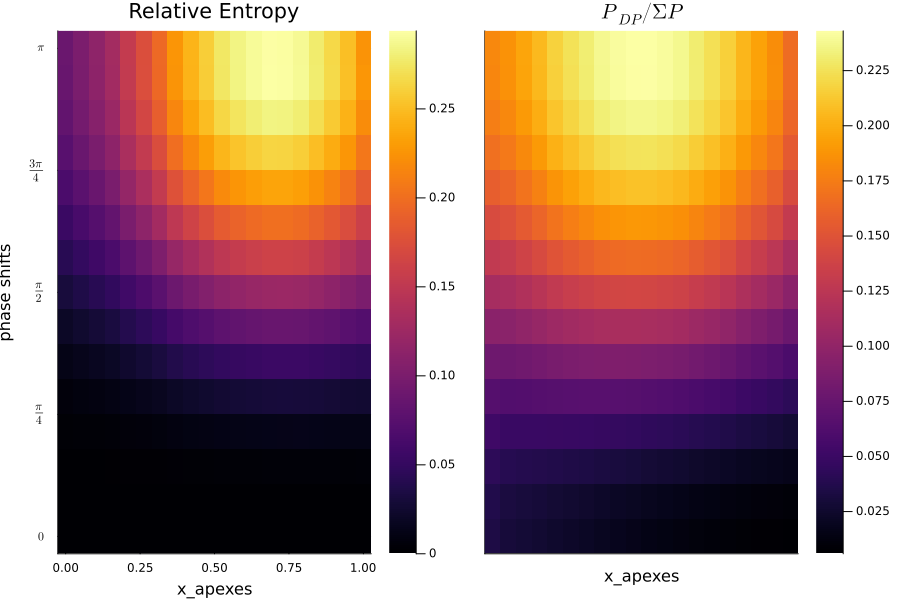

In [21]:
ticks = collect(0:π/4:π)
labels = [L"0", L"\frac{\pi}{4}", L"\frac{\pi}{2}", L"\frac{3\pi}{4}", L"\pi"]
fig1 = heatmap(x_apexes, phase_shifts, entropy_vals;
        xlabel = "x_apexes", ylabel = "phase shifts",
        title = "Relative Entropy",
        yticks=(ticks, labels)
    )

fig2 = heatmap(x_apexes, phase_shifts, mode_probs_masked,
                ylabel="",
                xlabel = "x_apexes",
                xticks = false, 
                yticks = false,
                title = L" P_{DP}/\Sigma P"
                )


plot(fig1, fig2, layout = (1,2), size = (900, 600))
# display(fig2)

(15, 20, 64)
(0.24304715829764684, CartesianIndex(15, 10))
(0.29385489491758465, CartesianIndex(14, 14))
CartesianIndex(11, 13)


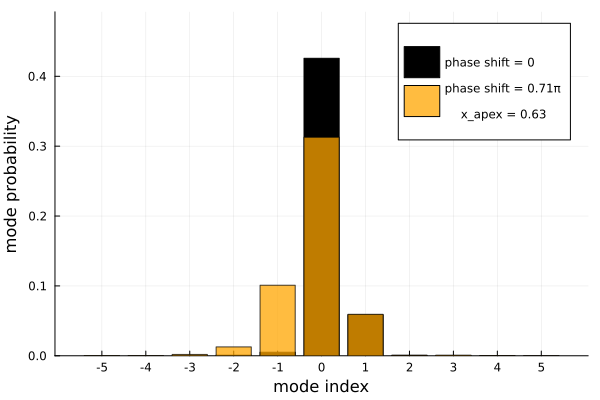

In [22]:
println(size(mode_probs))
println(findmax(mode_probs_masked))
println(findmax(entropy_vals))
plotting_crds = findmax(mode_probs_masked)[2] .- CartesianIndex(4,-3)
println(plotting_crds)
i = 1
j = findmax(entropy_vals)[2][2]
mode_prob = mode_probs[i,j,:]
width = 5
mode_mask = collect(-width:1:width) .+ (length(mode_prob)÷2 .+ 1)
mode_label = collect(-width:1:width)

fig1 = bar(mode_label,
    mode_prob[mode_mask],
    xlabel="mode index", 
    ylabel="mode probability", 
    legend=false, 
    color=:black,
    label = "phase shift = 0",
    xticks=(mode_label, string.(mode_label)),
    ylims = (0,maximum_probability),
)

bar!(mode_label, 
    mode_probs[plotting_crds,:][mode_mask], 
    legend=true, 
    opacity=0.75, 
    color=:orange,
    label = "phase shift = $(round(phase_shifts[plotting_crds[1]]/pi, digits=2))π \n 
    x_apex = $(round(x_apexes[plotting_crds[2]], digits=2))"
)

In [23]:
function find_crossings(x::AbstractVector, func::AbstractVector, y_point::Number)
    N = length(func)
    f = func .- y_point
    x_intercepts = []

    for i in 1:N-1
        if f[i]*f[i+1] < 0
            # Linear interpolation to find the crossing point
            dfdx = (f[i+1] - f[i]) / (x[i+1] - x[i])
            x_intercept = x[i] - f[i]/dfdx
            x_intercepts = push!(x_intercepts, x_intercept)
        end
        
    end
    return x_intercepts
end
p = 0.20
q = 0.05
k = 1:1:1000
z = -2.0
p_σ = @. ( p + z * sqrt(p/k))
y_test = @. 1/2 * log(q/p) + k * ( (p_σ - q)^2 / (2 * q) - (p_σ - p) ^2 / (2 * p) );


In [24]:
function bayes_factors(ps::AbstractMatrix, qs::AbstractVector, z::Real)
    N_electrons = 1:1:1_000_000
    N_electrons_required = similar(ps)

    looping_factor = size(ps,1) ÷ length(qs)
    for i in 1:size(ps, 1)
        for j in 1:size(ps, 2)
            p = ps[i, j]
            q = qs[j]
            
            p_σ = @. ( p + z * sqrt(p/N_electrons))
            # bayes_factor = @. 1/2 * log(q/p) + N_electrons * ( (p_σ - q)^2 / (2 * q) - (p_σ - p) ^2 / (2 * p) ) #gaussian approx
            bayes_factor = @. N * ( p_σ * log(p/q) - (p - q)) #poisson without considering 
            electron_crossings = find_crossings(N_electrons, bayes_factor, 0.0)
             
            if isempty(electron_crossings)
                N_electrons_required[i, j] = 1
            else
                N_electrons_required[i,j] = ceil(maximum(electron_crossings))
            end
        end
    end
        
    
    return N_electrons_required
end


bayes_factors (generic function with 1 method)

In [25]:
K = bayes_factors(mode_probs[:,:, idx], mode_probs[1, :, idx], -5.0);
N_sampling_electrons(p_w, p_wo, σ) = @. -σ * sqrt(ps) /( ps - (ps-q)/log.(ps/q) )

N_sampling_electrons (generic function with 1 method)

(14, 20) (1, 20)
(14, 20)


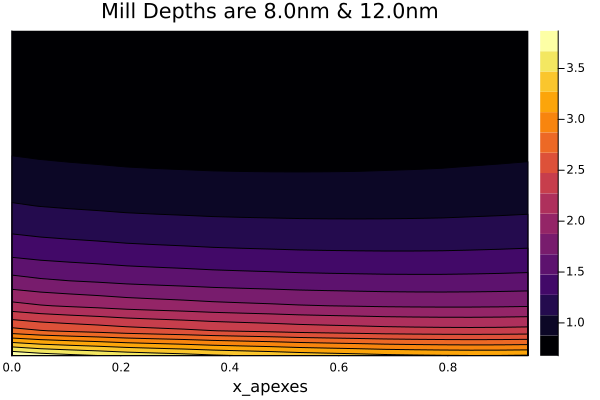

In [26]:
q = mode_probs[1, :, idx]'
ps = mode_probs[2:end,:, idx]
println(size(ps), " ", size(q))
z=-2
# K_check = @. -z * sqrt(ps) * inv( ps - (ps-q)/log.(ps/q) )
K_check = N_sampling_electrons(ps, q, z)
println(size(K_check))
# K_check = K_check[:, 1:end-1]
K_check .= K_check.^2 
K_check .= K_check .* C1s'


mill_key(mill_depths::AbstractVector) = join(string.(round.(mill_depths ./ 10; digits=2)) .* "nm", " & ")

heatmap(x_apexes[1:end-1] , phase_shifts[2:end], log10.(K_check[:,1:end-1]);
        title="Mill Depths are $(mill_key(mill_depths))",
        xlabel="x_apexes", ylabel="", yticks=false
        )
contourf(x_apexes[1:end-1] , phase_shifts[2:end], log10.(K_check[:,1:end-1]);
        title="Mill Depths are $(mill_key(mill_depths))",
        xlabel="x_apexes", ylabel="", yticks=false
        )

In [27]:
# K_check .= K_check .* C1s'

# create dictionary and store the matrix (use whichever result you want, e.g. K_check or K_altered)
if !isdefined(Main, :results_by_mill) || !(results_by_mill isa Dict)
    @info "Creating results_by_mill Dict"
    global results_by_mill = Dict{String, Any}()
else
    @info "results_by_mill already exists — keeping current value"
end
results_by_mill[mill_key(mill_depths)] = mode_probs, K_check, C1s
println(size(mode_probs), " ", size(K_check), " ", size(C1s))
# [ps[end,:]./q', ps[end,:], K_check[end, :]]   # or = K_altered, = ψs_imaged, etc.
# delete!(results_by_mill, "5.2nm & 5.2nm")

# example access / print
println("Stored result for key: ", mill_key(mill_depths))
println("Keys in dict: ", keys(results_by_mill))
println("Result: ", typeof(results_by_mill[mill_key(mill_depths)]))

(15, 20, 64) (14, 20) (

┌ Info: Creating results_by_mill Dict
└ @ Main /home/nicolas/Desktop/julia_functions/IFM/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X36sZmlsZQ==.jl:5


20,)
Stored result for key: 8.0nm & 12.0nm
Keys in dict: ["8.0nm & 12.0nm"]
Result: Tuple{Array{Float64, 3}, Matrix{Float64}, Vector{Any}}


In [28]:
function extract_first_number(s::AbstractString)
    m = match(r"([-+]?\d*\.?\d+)", s)
    return m === nothing ? NaN : parse(Float64, m.captures[1])
end
function extract_two_numbers(s::AbstractString)
    ms = collect(eachmatch(r"([-+]?\\d*\\.?\\d+)", s))
    nums = [parse(Float64, m.match) for m in ms]
    a = length(nums) >= 1 ? nums[1] : NaN
    b = length(nums) >= 2 ? nums[2] : NaN
    return (a, b)
end
sorted_keys = sort(collect(keys(results_by_mill)), by=extract_first_number)
# sorted_keys = sort(collect(sorted_keys), by=extract_two_numbers)

1-element Vector{String}:
 "8.0nm & 12.0nm"

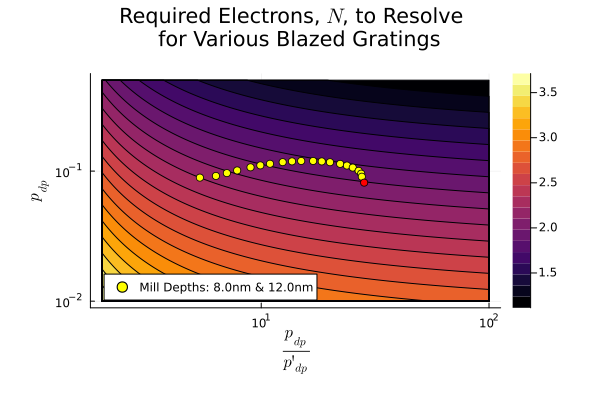

In [29]:
ps = collect(0.01:0.001:0.5)
prs = collect(2.0:0.01:100)
prs = prs'
z=-2
k_2d = @. -z * prs /( prs + (1-prs)/log(prs) ) /(sqrt(ps))
k_2d .= k_2d.^2
# ficticious_ps = @. (-z * prs * inv( prs + (1-prs)/log(prs) ) * inv(sqrt(K_check[end, :])))^2
# fig = heatmap(prs', ps, log10.(k_2d),
#                 xlabel=L"\frac{p_{dp}}{p'_{dp}}",
#                 ylabel=L"p_{dp}",
#                 title="Required Electrons, "*L"N" *", to Resolve \n for Various Blazed Gratings"
# )
fig = contourf(prs', ps, log10.(k_2d);
        xlabel=L"\frac{p_{dp}}{p'_{dp}}",
        ylabel=L"p_{dp}",
        title="Required Electrons, "*L"N" *", to Resolve \n for Various Blazed Gratings",
        levels=20,
        xscale=:log10,
        yscale=:log10
    )


colors = [:blue, :green, :orange, :brown, :pink, :gray]
colors = ["#FFFF00", "#00FFFF", "#00FF00", :pink, "#FF7F00", "#008080"  , "#8B00FF"]
colors = [
    "#FFFF00", # Yellow
    "#FFD700", # Gold
    "#FF7F00", # Orange
    # "#FF4500", # OrangeRed
    # "#FF0000", # Red
    "#7CFC00", # LawnGreen
    "#00FF7F", # SpringGreen
    "#00FFFF", # Cyan
    "#1E90FF", # DodgerBlue
    "#FFFFFF"  # White
]

if isempty(results_by_mill)
    @warn "results_by_mill is empty — nothing to overlay"
else
    # for (i, key) in enumerate(keys(results_by_mill))
    for (i, key) in enumerate(sorted_keys)


        dic_result = results_by_mill[key]
        local p_dp_w = dic_result[1][end, :, idx] # (object inserted) using (π, all x_apexes, dark mode) w/ [end, :, idx]
        local p_dp_wo = dic_result[1][1, :, idx] # (object removed) using (0, all x_apexes, dark mode) w/ [1, :, idx]
        @assert length(p_dp_w) == length(p_dp_wo) "p_dp_w/p_dp_wo length mismatch of $(length(p_dp_w)) and $(length(p_dp_wo)) for key=$key"
        local x = @. p_dp_w / p_dp_wo
        local y = @. p_dp_w
        scatter!(fig, 
                    x[1:end-1], 
                    y[1:end-1]; 
                    ms=4, 
                    mc=colors[i], 
                    label="Mill Depths: $key")
        scatter!(fig, 
                    [x[end]], 
                    [y[end]]; 
                    ms=4, 
                    mc=:red, 
                    label="")
        
    end
end
plot(fig, legend=:bottomleft, margins=(8, :mm))


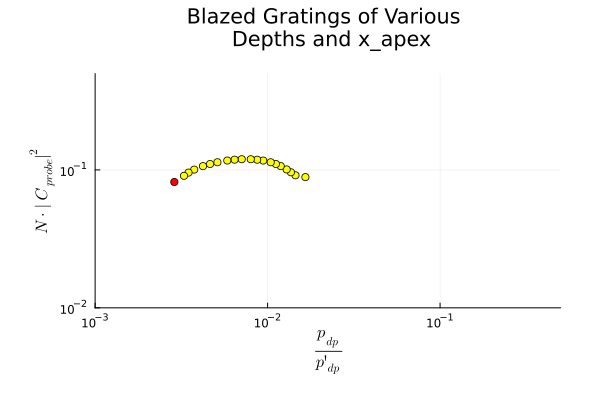

In [30]:
ps = collect(0.1:0.001:3.2)
prs = collect(3.0:0.01:50)
prs = prs'
z=-2
k_2d = @. -z * prs * inv( prs + (1-prs)/log(prs) ) * inv(sqrt(ps))
k_2d .= k_2d.^2
fig2 = heatmap(prs', ps, log10.(k_2d), 
                xlabel="Ficticious " * L"\frac{p_{pd}}{p'_{dp}}",
                xticks=false,
                ylabel="Ficticious " * L"p_{dp}",
                yticks=false,
                title="Damage to Sample, Proporationally,  \n for Various Blazed Gratings"
)
fig2 = contourf(prs', ps, log10.(k_2d), 
                xlabel="Ficticious " * L"\frac{p_{pd}}{p'_{dp}}",
                xticks=false,
                ylabel="Ficticious " * L"p_{dp}",
                yticks=false,
                title="Damage to Sample, Proporationally,  \n for Various Blazed Gratings",
                yscale = :log10,
                xscale = :log10,
)
y_tot = []
C1s_tot = []
z_tot = []
fig2 = scatter()



if isempty(results_by_mill)
    @warn "results_by_mill is empty — nothing to overlay"
else
    # for (i, key) in enumerate(keys(results_by_mill))
    for (i, key) in enumerate(sorted_keys)


        dic_result = results_by_mill[key]
        if length(dic_result) != 3
            @warn "Skipping key"
            continue
        end
        phase_idx = length(phase_shifts) -1
        mode_idx_shift = 0
        local p_dp_w = dic_result[1][phase_idx, :, idx+mode_idx_shift] # (object inserted) using (π, all x_apexes, dark mode) w/ [end, :, idx]
        local p_dp_wo = dic_result[1][1, :, idx+mode_idx_shift] # (object removed) using (0, all x_apexes, dark mode) w/ [1, :, idx]
        @assert length(p_dp_w) == length(p_dp_wo) "p_dp_w/p_dp_wo length mismatch of $(length(p_dp_w)) and $(length(p_dp_wo)) for key=$key"
        local prs = @. p_dp_w / p_dp_wo
        local N_sample_plane = dic_result[2][phase_idx, :]
        local C1s = dic_result[3]
        local x_plot = p_dp_wo
        local y_plot = p_dp_w
        # local x_plot = p_dp_w
        # local y_plot = N_sample_plane.* C1s
        # local y_plot = prs

        C1s_tot = vcat(C1s_tot, x_plot)
        y_tot = vcat(y_tot, y_plot)
        z_tot = vcat(z_tot, N_sample_plane.* C1s)
        
        scatter!(fig2, 
                    x_plot[1:end-1], 
                    y_plot[1:end-1], 
                    #zcolor=log10.(N_sample_plane[1:end-1]); 
                    ms=4, 
                    mc=colors[i], 
                    label="Mill Depths: $key")
        scatter!(fig2, 
                    [x_plot[end]], 
                    [y_plot[end]], 
                    #zcolor=log10.(N_sample_plane[end]); 
                    ms=4, 
                    mc=:red, 
                    label="")


        
    end
end

plot(fig2, 
    # legend=:bottomright,
    # legend=:topleft,
    legend=false,
    yscale=:log10,
    xscale=:log10,
    margins=(8, :mm)
)
xlabel!(L"\frac{p_{dp}}{p'_{dp}}")
# ylabel!(L"p_{dp}")
ylabel!(L"N\cdot |C_{probe}|^2")
title!("Blazed Gratings of Various \n Depths and x_apex")

# choose axis limits
# xmin, xmax = 1e-0, 1e3
xmin, xmax = 1e-3, 0.5*1e0
# xmin, xmax = 1e-0, 1e3

# Option A — ticks at exact decades (1e-4, 1e-3, 1e-2, 1e-1)
decade_ticks = 10 .^ collect(floor(log10(xmin)):ceil(log10(xmax)))
decade_labels = ("10^{$(Int).(log10.(decade_ticks))}")  # LaTeX labels like 10^{-4}, ...
# xscale!(:log10)
xticks!(decade_ticks)
xlims!(xmin, xmax)
ylims!(1e-2, 0.5)
# ylims!(1, 50)
yticks!(decade_ticks)



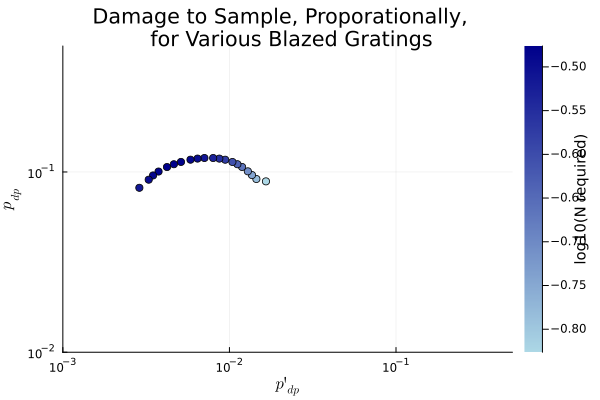

In [31]:
plot(C1s_tot, y_tot, seriestype=:scatter, zcolor=log10.(z_tot),
    xscale=:log10,
    yscale=:log10,
    # xlabel=L"|C_{probe}|^2",
    # ylabel=L"\frac{p_{dp}}{p'_{dp}}",
    title="Damage to Sample, Proporationally,  \n for Various Blazed Gratings",
    color=:blues,
    colorbar=true,
    legend=false,
    colorbar_title = "log10(N required)"
)
xlabel!(L"p'_{dp}")
ylabel!(L"p_{dp}")
xticks!(decade_ticks)
xlims!(xmin, xmax)
yticks!(decade_ticks)
ylims!(1e-2, 0.5)

# ylims!(minimum(y_tot), maximum(y_tot)*1.1)

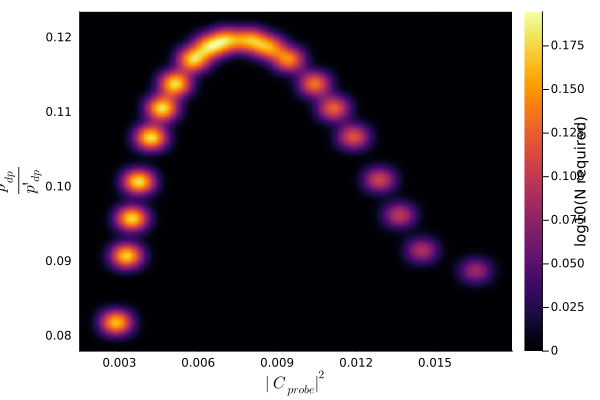

In [32]:
using ImageFiltering
function plotting_axis_maker(x_points::AbstractVector, adjustment::Real=0.05; N=0)
    xmin, xmax = minimum(x_points), maximum(x_points)
    xrange = xmax - xmin
    xmin_adjusted = xmin - adjustment * xrange
    xmax_adjusted = xmax + adjustment * xrange
    if N > 0
        return collect(range(xmin_adjusted, stop=xmax_adjusted, length=N))
    end
    return collect(range(xmin_adjusted, stop=xmax_adjusted, length=2*length(x_points)))
end



function Z_grid(x_points::AbstractVector, 
                y_points::AbstractVector, 
                z_points::AbstractVector,
                blur::Tuple{Bool, Real} = (true, 5)
                )
    """
        Build a grid Z from scattered data points (x_points, y_points, z_points).
    """
    # build grid of unique sorted coordinates
    local Nx = 500
    local Ny = 500
    # local xs = collect(range(minimum(x_points), stop=maximum(x_points), length=Nx))
    # local ys = collect(range(minimum(y_points), stop=maximum(y_points), length=Ny))
    
    local xs = plotting_axis_maker(x_points, 0.1, N=Nx)
    local ys = plotting_axis_maker(y_points, 0.1, N=Ny)
    local Z = zeros(Nx, Ny)

    
    radius = round(Int,20) 
    x_radius = collect(-radius:1:radius)
    y_radius = collect(-radius:1:radius)
    gaussian_point = @. exp( - ( x_radius'^2 + y_radius^2) / (2 * (radius/2)^2) )

    for (x_point,y_point,z_point) in zip(x_points, y_points, z_points)
        idx_x = findmin(abs.(xs .- x_point))[2]
        idx_y = findmin(abs.(ys .- y_point))[2]
        
        mask = (max(1, idx_y - radius):1:min(Nx, idx_y + radius),
                max(1, idx_x - radius):1:min(Ny, idx_x + radius))
       
        Z[mask...] .= max.(z_point.*gaussian_point, Z[mask...])
        # Z[idx_y, idx_x] = max(z_point, Z[idx_y, idx_x])
    end
    if blur[1]
        
        kernel = Kernel.gaussian(blur[2])
        # local Z = imfilter(Z, kernel,Pad(:reflect))
        local Z = imfilter(Z, kernel, Fill(0))
    end
    return xs, ys, Z, gaussian_point
end

x_plotting, y_plotting, z_plotting, gaussian_point = Z_grid(C1s_tot, y_tot, z_tot, (true, 10))

heatmap(x_plotting, y_plotting, (z_plotting);
        xlabel=L"|C_{probe}|^2",
        ylabel=L"\frac{p_{dp}}{p'_{dp}}",
        title="",
        colorbar_title = "log10(N required)"
    )

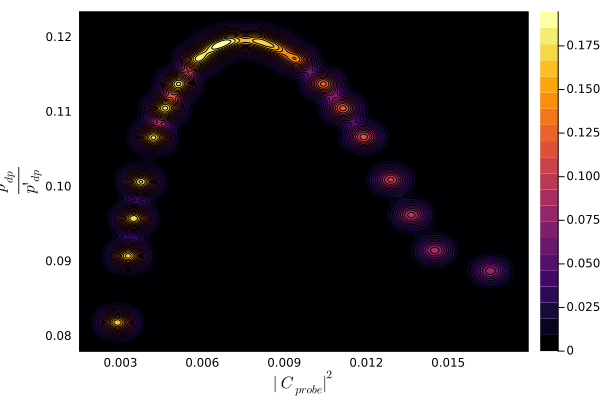

In [33]:
contourf(x_plotting, y_plotting, (z_plotting);
        xlabel=L"|C_{probe}|^2",
        ylabel=L"\frac{p_{dp}}{p'_{dp}}",
        title="",
        colorbar_title = "",
        levels=20,
    )